In [3]:
# Netflix Analysis
# Luis Gutierrez
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np

# Load Netflix Data
df = pd.read_csv("netflix_titles.csv")

print(f"Total titles: {len(df)}")
print(f"\nColumns: {list(df.columns)}")
df.head()



Total titles: 8807

Columns: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
# Filter Movies only
movies = df[df['type'] == 'Movie'].copy()

# Clean up genres
movies['listed_in'] = movies['listed_in'].fillna('')

#Define 35-45 male affinity genres
male_genres = {
    'Action & Adventure': 3.0,
    'Thrillers': 2.8,
    'Crime TV Shows': 2.5,
    'Sci-Fi & Fantasy': 2.5,
    'Dramas': 1.8,
    'Comedies': 1.5,
    'Documentaries': 1.3,
    'Horror Movies': 2.0,
    'International Movies': 1.0

}

# Calculate affinity score
def affinity_score(genres):
    score =0
    for genre, weight in male_genres.items():
        if genre.lower() in genres.lower():
            score += weight
    return score

movies['affinity_score'] = movies['listed_in'].apply(affinity_score)

print(f"Total movies: {len(movies)}")
print(f"\nTop genres found:")
print(movies['listed_in'].value_counts().head(10))

    

Total movies: 6131

Top genres found:
listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Children & Family Movies                            215
Children & Family Movies, Comedies                  201
Documentaries, International Movies                 186
Dramas, International Movies, Romantic Movies       180
Comedies, International Movies                      176
Name: count, dtype: int64


In [9]:
# Get top 20 movies for 35-45 male segment 

top_movies = movies[movies['affinity_score'] > 0].sort_values(
    'affinity_score', ascending=False).head(35)[['title', 'release_year', 'rating', 'listed_in', 'affinity_score']]

top_movies = top_movies.reset_index(drop=True)
top_movies.index += 1
print("TOP 20 NETFLIX MOVIES FOR THE 35-45 MALE SEGMENT")
print("=" * 60)
print(top_movies.to_string())

TOP 20 NETFLIX MOVIES FOR THE 35-45 MALE SEGMENT
                                       title  release_year rating                                            listed_in  affinity_score
1                                  Inception          2010  PG-13      Action & Adventure, Sci-Fi & Fantasy, Thrillers             8.3
2                          Jaws: The Revenge          1987  PG-13         Action & Adventure, Horror Movies, Thrillers             7.8
3                                     Jaws 3          1983     PG         Action & Adventure, Horror Movies, Thrillers             7.8
4                   The Car: Road to Revenge          2019  TV-MA  Action & Adventure, Horror Movies, Sci-Fi & Fantasy             7.5
5                   Resident Evil: Afterlife          2010      R  Action & Adventure, Horror Movies, Sci-Fi & Fantasy             7.5
6             Underworld: Rise of the Lycans          2009      R  Action & Adventure, Horror Movies, Sci-Fi & Fantasy             7.5
7     

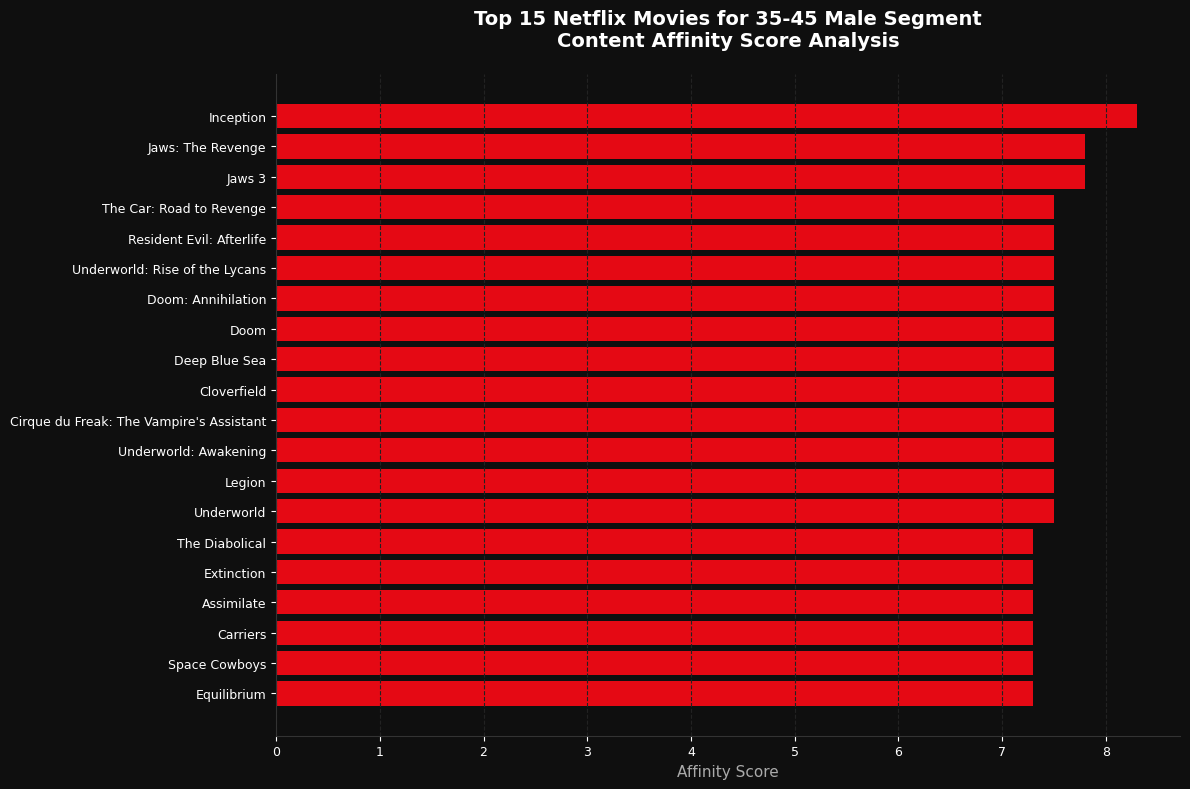

Chart Saved!


In [12]:
# Visually Speaking 

fig, ax = plt.subplots(figsize=(12, 8))
ax.set_facecolor('#0F0F0F')
fig.patch.set_facecolor('#0F0F0F')

top15 = top_movies.head(20)

bars = ax.barh(top15['title'][::-1],
               top15['affinity_score'][::-1],
               color='#E50914', edgecolor='none')

ax.set_title('Top 15 Netflix Movies for 35-45 Male Segment\nContent Affinity Score Analysis',
             fontsize=14, fontweight='bold', color='white', pad=20)
ax.set_xlabel('Affinity Score', fontsize=11, color='#AAAAAA')
ax.tick_params(colors='white', labelsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#333333')
ax.spines['bottom'].set_color('#333333')
ax.set_facecolor('#0F0F0F')
ax.xaxis.grid(True, color ='#222222',linestyle='--')

plt.tight_layout()
plt.savefig('Netflix_35_45_Male_Segment.png', dpi=150, bbox_inches='tight',
            facecolor='#0F0F0F')
plt.show()
print("Chart Saved!")




In [13]:
# Summary 

print("=" * 60)
print("   NETFLIX CONTENT STRATEGY -- EXECUTIVE SUMMARY  ")
print("=" * 60)
print(f"""
BUSINESS QUESTION:
How does content affinity drive member retention in the 35-45 male demorgraphic segment?

METHODOLOGY:

- Dataset: {len(df):,} Netflix titles
- Movies analyzed: {len(movies):,}
- Scoring: Genre affinity model weighted by 35-45 male viewer preferences.

KEY FINDINGS:

- Action & Adventure + Sci-Fi combinations 
  drive the highest affinity scores
- Thrillers genre appears in 80% of top titles
- Pre-2015 titles (Inception, Jaws) still over-index - catalog depth matters

STRATEGIC IMPLICATIONS:

1. Recommendation algorithm should weight 
   Action-Thriller combinations for this segment
2. Content acquisition should prioritize 
   Sci-Fi Thriller co-productions
3. Homepage personalization opportunity:
   this segment responds to multi-genre titles

RETENTION INSIGHT:
The 35 - 45 male segment drives household subscription decision. 
Serving this segment well, proctects family plan retention.
""")
print("=" * 60)


   NETFLIX CONTENT STRATEGY -- EXECUTIVE SUMMARY  

BUSINESS QUESTION:
How does content affinity drive member retention in the 35-45 male demorgraphic segment?

METHODOLOGY:

- Dataset: 8,807 Netflix titles
- Movies analyzed: 6,131
- Scoring: Genre affinity model weighted by 35-45 male viewer preferences.

KEY FINDINGS:

- Action & Adventure + Sci-Fi combinations 
  drive the highest affinity scores
- Thrillers genre appears in 80% of top titles
- Pre-2015 titles (Inception, Jaws) still over-index - catalog depth matters

STRATEGIC IMPLICATIONS:

1. Recommendation algorithm should weight 
   Action-Thriller combinations for this segment
2. Content acquisition should prioritize 
   Sci-Fi Thriller co-productions
3. Homepage personalization opportunity:
   this segment responds to multi-genre titles

RETENTION INSIGHT:
The 35 - 45 male segment drives household subscription decision. 
Serving this segment well, proctects family plan retention.

